In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Dataset.csv',index_col='instant')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 1 to 17379
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   dteday      17379 non-null  object
 1   season      17379 non-null  object
 2   yr          17379 non-null  object
 3   mnth        17379 non-null  object
 4   hr          17379 non-null  int64 
 5   holiday     17379 non-null  object
 6   weekday     17379 non-null  int64 
 7   workingday  17379 non-null  object
 8   weathersit  17379 non-null  object
 9   temp        17379 non-null  object
 10  atemp       17379 non-null  object
 11  hum         17379 non-null  object
 12  windspeed   17379 non-null  object
 13  casual      17379 non-null  object
 14  registered  17379 non-null  object
 15  cnt         17379 non-null  int64 
dtypes: int64(3), object(13)
memory usage: 2.3+ MB


In [4]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,,
1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [5]:
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y')


In [6]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,,
1,2011-01-01,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
2,2011-01-01,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
3,2011-01-01,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
4,2011-01-01,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
5,2011-01-01,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [7]:
df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
"""for i in df.columns:
    print(i)
    print(df[i].unique())"""

'for i in df.columns:\n    print(i)\n    print(df[i].unique())'

In [10]:
for i in df.columns:
    if '?' in df[i].unique():
        df[i] = df[i].replace('?', np.nan)

In [11]:
df.isnull().sum()

dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

In [12]:
df.fillna({
    'season':df['season'].mode()[0],
    'holiday':df['holiday'].mode()[0],
    'workingday':df['workingday'].mode()[0],
    'weathersit':df['weathersit'].mode()[0]
},inplace=True)

In [13]:
df['yr'] = df['yr'].fillna(method='ffill')
df['mnth'] = df['mnth'].fillna(method='ffill')

In [14]:
df['temp']=df['temp'].astype(float)
df['atemp']=df['atemp'].astype(float)
df['hum']=df['hum'].astype(float)
df['windspeed']=df['windspeed'].astype(float)
df['casual']=df['casual'].astype(float)
df['registered']=df['registered'].astype(float)
df['yr']=df['yr'].astype(int)
df['mnth']=df['mnth'].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 1 to 17379
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[ns]
 1   season      17379 non-null  object        
 2   yr          17379 non-null  int32         
 3   mnth        17379 non-null  int32         
 4   hr          17379 non-null  int64         
 5   holiday     17379 non-null  object        
 6   weekday     17379 non-null  int64         
 7   workingday  17379 non-null  object        
 8   weathersit  17379 non-null  object        
 9   temp        17368 non-null  float64       
 10  atemp       17373 non-null  float64       
 11  hum         17373 non-null  float64       
 12  windspeed   17374 non-null  float64       
 13  casual      17378 non-null  float64       
 14  registered  17378 non-null  float64       
 15  cnt         17379 non-null  int64         
dtypes: datetime64[ns](1), float

In [16]:
df.fillna({
    'temp':df['temp'].mean(),
    'atemp':df['atemp'].mean(),
    'hum':df['hum'].mean(),
    'windspeed':df['windspeed'].mean(),
    'casual':df['casual'].mode()[0],
    'registered':df['registered'].mode()[0]
},inplace=True)

In [17]:
# outliers detection

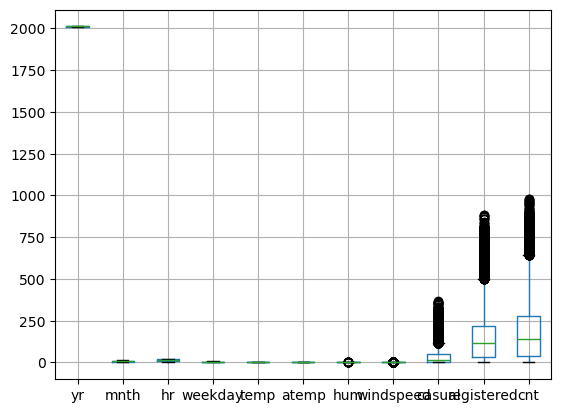

In [18]:
df.boxplot()
plt.show()

In [19]:
def outlier_capping(df,columns):
    q1=df[columns].quantile(0.25)
    q3=df[columns].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    upper_extreme=q3+1.5*iqr
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

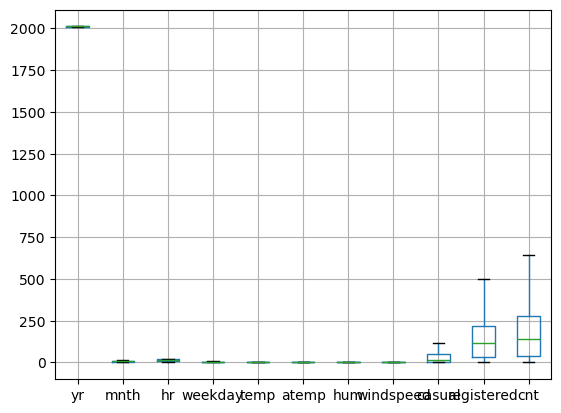

In [20]:
df.boxplot()
plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 1 to 17379
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[ns]
 1   season      17379 non-null  object        
 2   yr          17379 non-null  int64         
 3   mnth        17379 non-null  int64         
 4   hr          17379 non-null  int64         
 5   holiday     17379 non-null  object        
 6   weekday     17379 non-null  int64         
 7   workingday  17379 non-null  object        
 8   weathersit  17379 non-null  object        
 9   temp        17379 non-null  float64       
 10  atemp       17379 non-null  float64       
 11  hum         17379 non-null  float64       
 12  windspeed   17379 non-null  float64       
 13  casual      17379 non-null  float64       
 14  registered  17379 non-null  float64       
 15  cnt         17379 non-null  float64       
dtypes: datetime64[ns](1), float

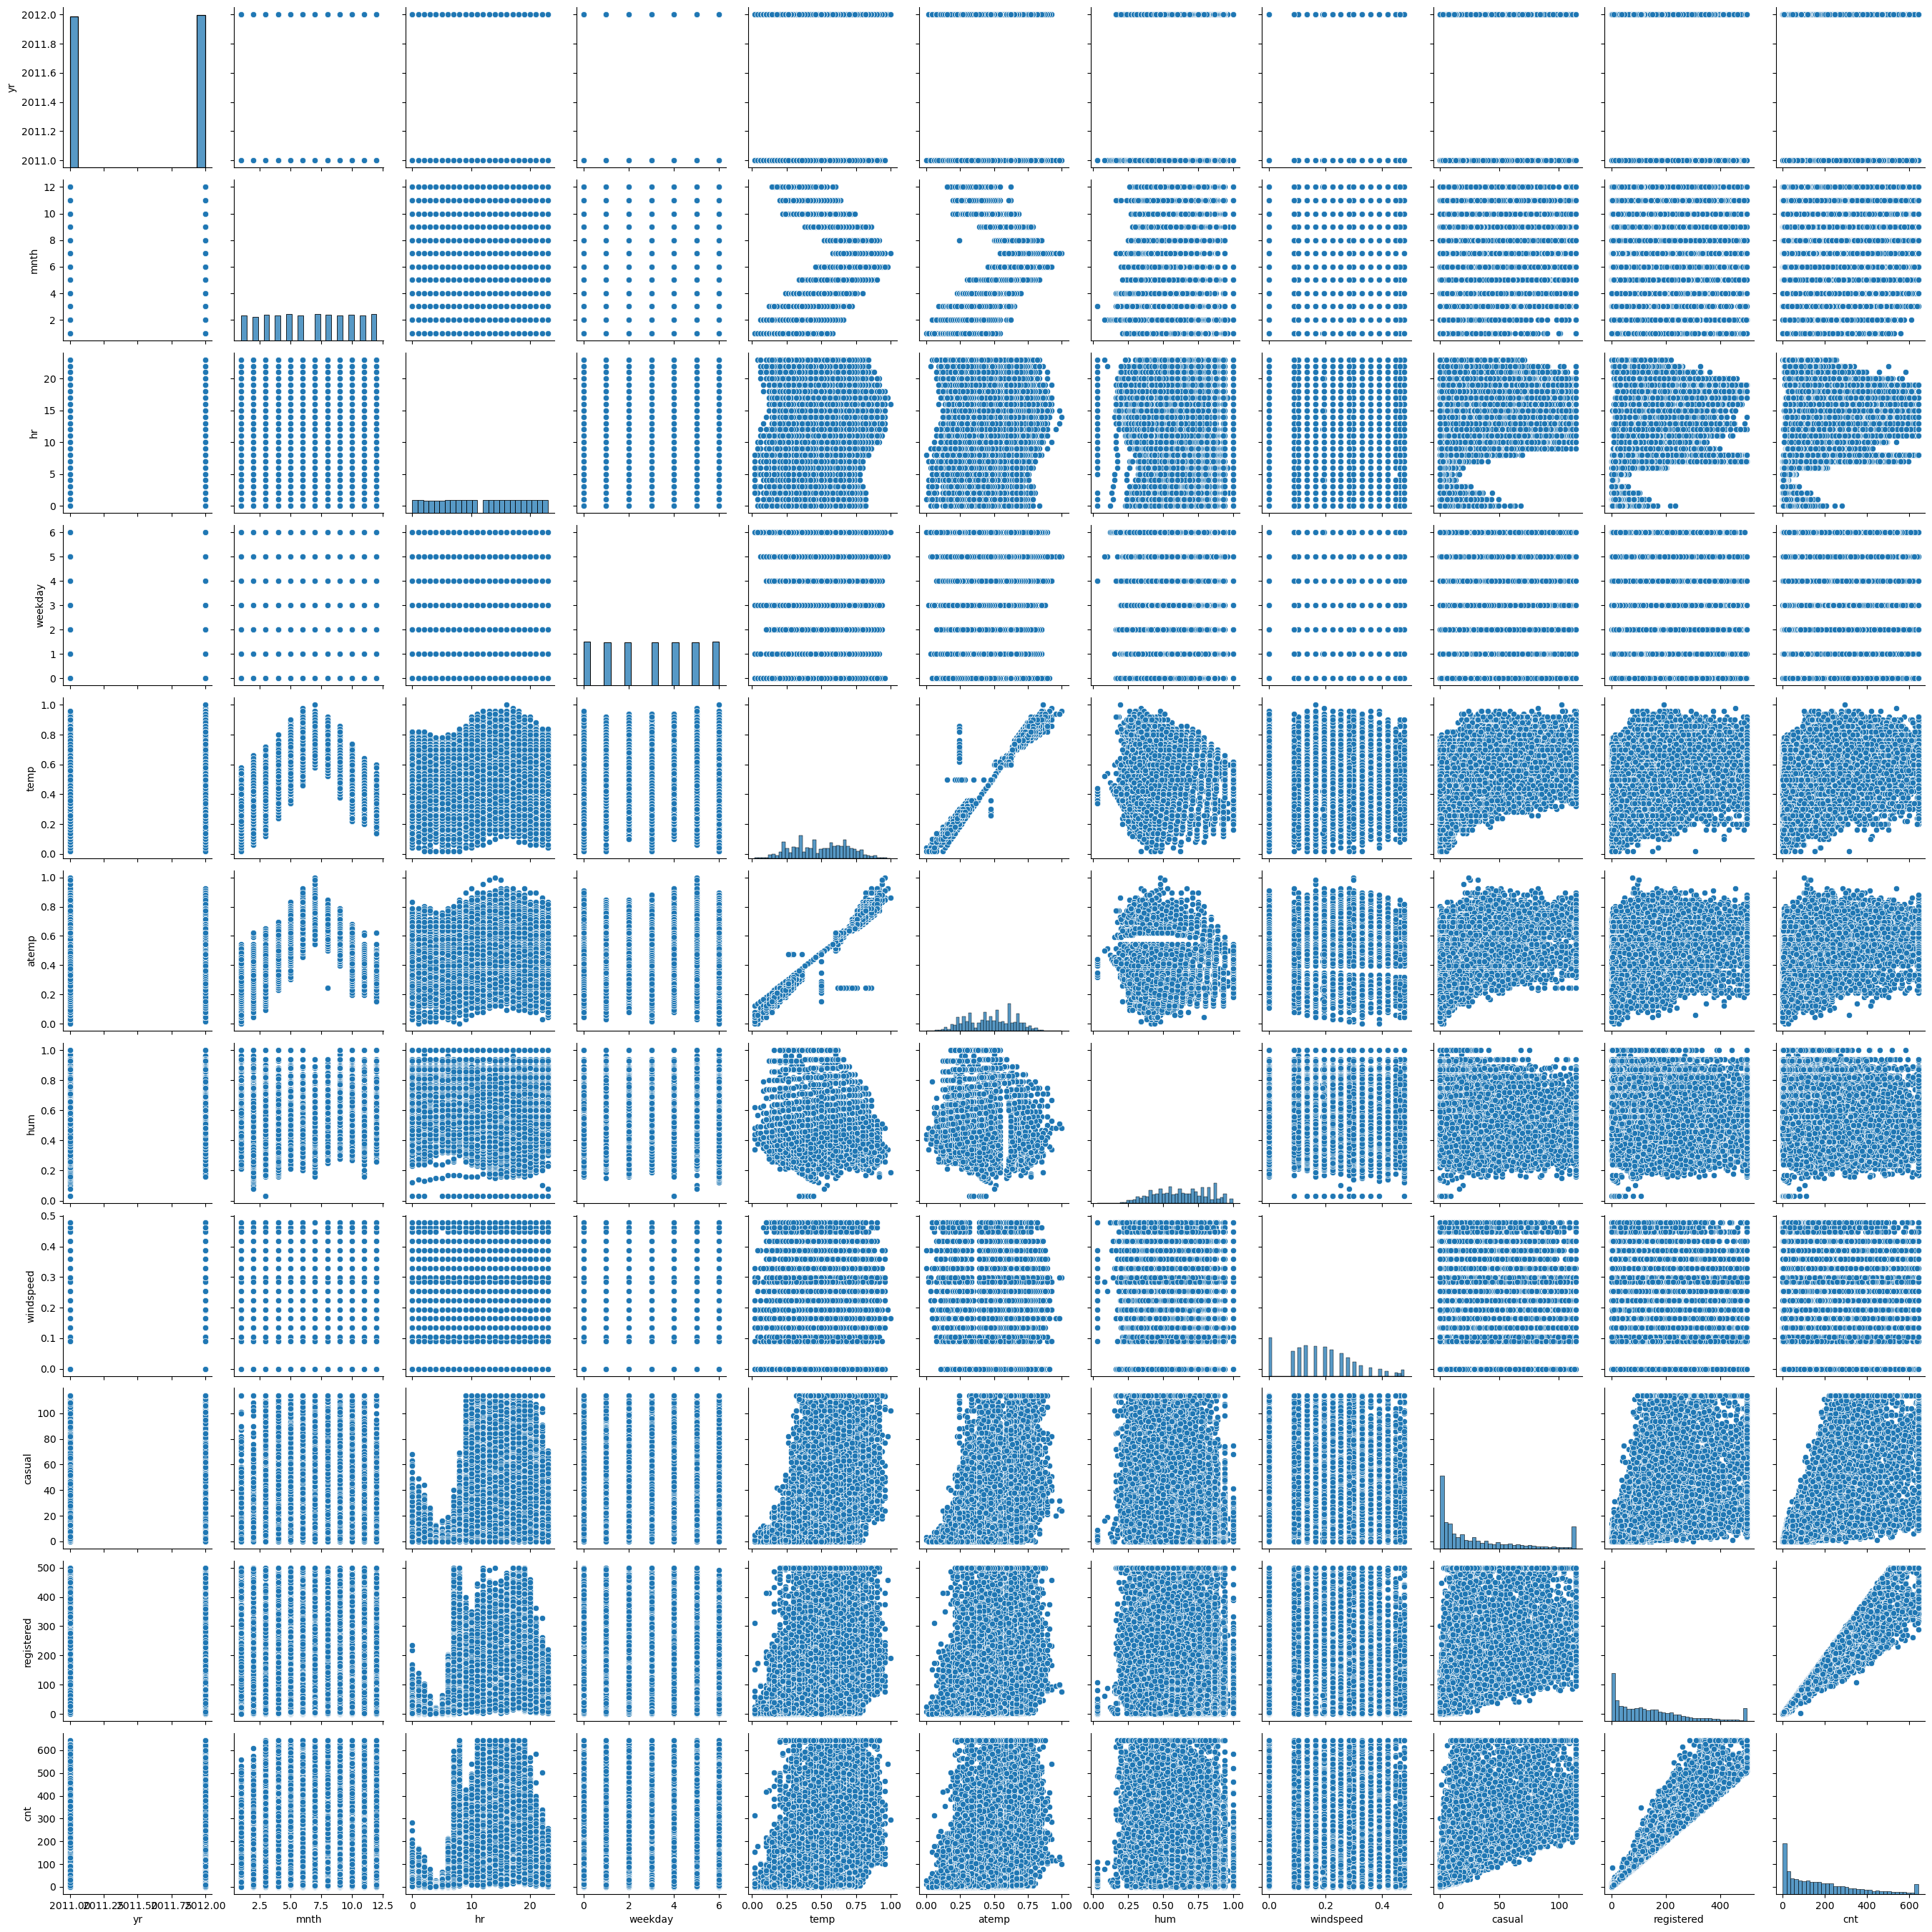

In [22]:
sns.pairplot(data=df)
plt.show()

In [23]:
target=df[['cnt']]
features=df.drop(columns=['cnt','dteday'])

In [24]:
from sklearn.preprocessing import OrdinalEncoder,StandardScaler

In [25]:
ord_enc=OrdinalEncoder()

In [26]:
for i in features.select_dtypes(['object']).columns:
    features[i]=ord_enc.fit_transform(features[[i]])

In [27]:
from sklearn.feature_selection import f_regression

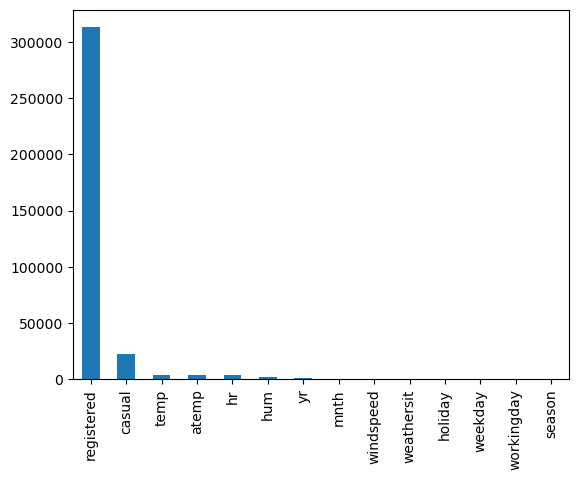

In [28]:
f_reg=f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [29]:
features.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')

In [30]:
features.drop(columns=['mnth','windspeed','weathersit','holiday','weekday','workingday','season'],inplace=True)

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(13903, 7)
(3476, 7)
(13903, 1)
(3476, 1)


In [33]:
std_sca=StandardScaler()

In [34]:
features=pd.DataFrame(std_sca.fit_transform(features),columns=features.columns)

In [35]:
features

,yr,hr,temp,atemp,hum,casual,registered
0,-1.005134,-1.670004,-1.336038e+00,-1.094047,0.947996,-0.808812,-1.002156
1,-1.005134,-1.525374,-1.439956e+00,-1.182525,0.896124,-0.665188,-0.861780
2,-1.005134,-1.380744,-1.439956e+00,-1.182525,-0.000197,-0.751363,-0.898721
3,-1.005134,-1.236115,-1.336038e+00,-1.094047,0.636760,-0.808812,-1.024320
4,-1.005134,-1.091485,-1.336038e+00,-1.094047,0.636760,-0.894987,-1.090815
...,...,...,...,...,...,...,...
17374,0.994892,1.077962,-1.232119e+00,-1.270420,-0.141331,-0.579013,-0.300274
17375,0.994892,1.222591,-1.232119e+00,-1.270420,-0.141331,-0.665188,-0.499756
17376,0.994892,1.367221,2.884321e-16,-1.270420,-0.141331,-0.693913,-0.484980
17377,0.994892,1.511851,-1.232119e+00,-1.182525,-0.348822,-0.521563,-0.743568


In [36]:
lin_mod=LinearRegression()
lin_mod.fit(x_train,y_train)
pred=lin_mod.predict(x_test)
r2_score(y_test,pred)

0.9882198453089858

In [37]:
# Decision Tree

In [38]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [39]:
dt=DecisionTreeRegressor(criterion='squared_error',
    splitter='best',
    max_depth=4)

In [40]:
dt.fit(x_train,y_train)
y_pred= dt.predict(x_test)
r2_score(y_test,y_pred)

0.9735863341629521

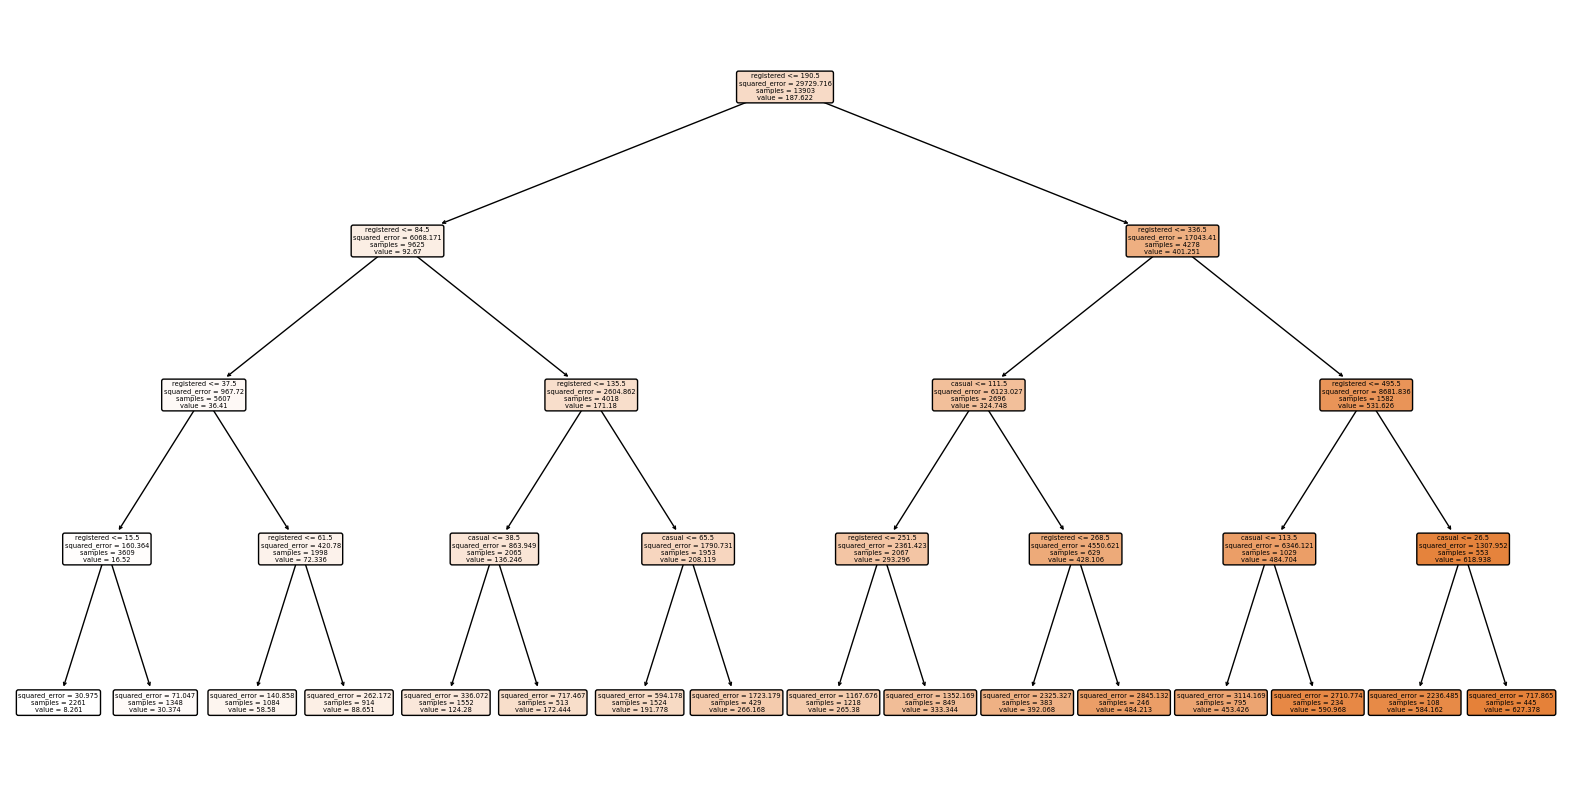

In [41]:
#### plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True,rounded=True,feature_names=list(features))
plt.show();

In [42]:
# hyper parameter tuning

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}


In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [46]:
grid_search.best_params_
grid_search.best_score_


0.9938044114112744

In [47]:
best_model = grid_search.best_estimator_

In [48]:
best_model.fit(x_train,y_train)
pred=best_model.predict(x_test)
r2_score(y_test,pred)

0.9942007250529296

#### Random forest

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)
y_pred= rf.predict(x_test)
r2_score(y_test,y_pred)

0.9960192372609569

In [51]:
# hyperparameter tuning

In [52]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


In [53]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [54]:
grid_search.best_params_
grid_search.best_score_


0.9948237135023463